In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Load dataset
df = pd.read_csv("hotel_bookings.csv")

# Overview functions
print("--- Head ---")
display(df.head())

print("\n--- Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Info ---")
df.info()

print("\n--- Describe ---")
display(df.describe())

print("\n--- Data Types ---")
print(df.dtypes)

# Class distribution of target variable
print("\n--- Target Variable Distribution (is_canceled) ---")
print(df['is_canceled'].value_counts(normalize=True))

--- Head ---


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



--- Shape ---
Rows: 119390, Columns: 32

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          11

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



--- Data Types ---
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent         

In [5]:
# Missing values analysis
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_pct})
print("--- Missing Values Summary ---")
display(missing_df[missing_df['Missing Count'] > 0])

# Drop high-missingness columns and leakage columns
# 'company' has ~94% missing values. 'agent' and 'country' will be handled by imputers.
# 'reservation_status' and 'reservation_status_date' directly reveal the target outcome (data leakage).
cols_to_drop = ['company', 'reservation_status', 'reservation_status_date']
df_cleaned = df.drop(columns=cols_to_drop)

print(f"\nDropped columns: {cols_to_drop}")
print(f"New dataset shape: {df_cleaned.shape}")

--- Missing Values Summary ---


,Missing Count,Percentage (%)
children,4,0.003350
country,488,0.408744
agent,16340,13.686238
company,112593,94.306893



Dropped columns: ['company', 'reservation_status', 'reservation_status_date']
New dataset shape: (119390, 29)


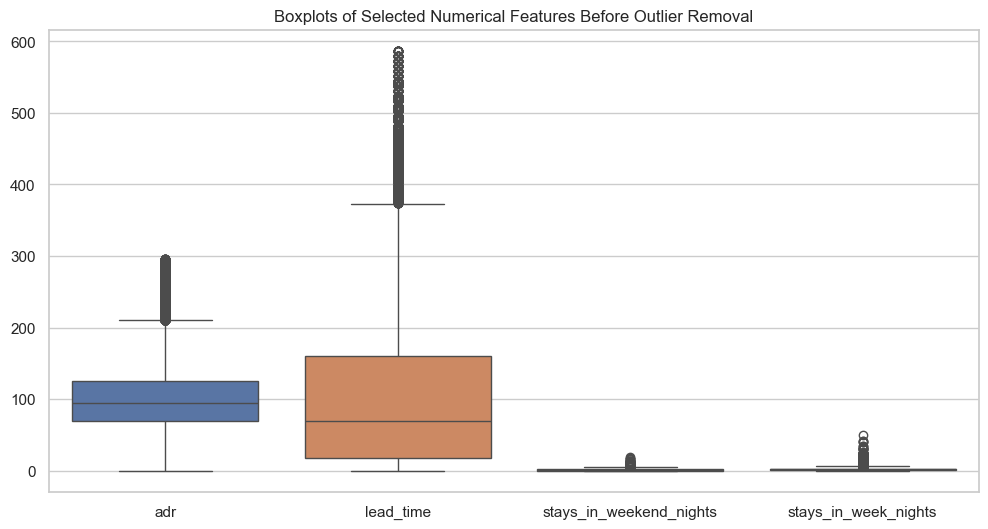

Removed 24 rows containing extreme outliers.
Remaining dataset shape: (118874, 29)


In [7]:
# Select key numerical features to inspect for extreme outliers
num_check_cols = ['adr', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights']

# Plot boxplots before cleaning
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned[num_check_cols])
plt.title("Boxplots of Selected Numerical Features Before Outlier Removal")
plt.show()

# Remove extreme outliers (e.g., negative adr or extreme high values)
initial_rows = len(df_cleaned)

# Remove adr < 0 or adr > 5000 (clear data entry errors/extreme spikes)
df_cleaned = df_cleaned[(df_cleaned['adr'] >= 0) & (df_cleaned['adr'] < 5000)]

# IQR Filter for adr and lead_time
for col in ['adr', 'lead_time']:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 3 * IQR  # Using 3*IQR to target only extreme outliers
    df_cleaned = df_cleaned[df_cleaned[col] <= upper_bound]

rows_removed = initial_rows - len(df_cleaned)
print(f"Removed {rows_removed} rows containing extreme outliers.")
print(f"Remaining dataset shape: {df_cleaned.shape}")

In [8]:
# Define features (X) and target (y)
X = df_cleaned.drop(columns=['is_canceled'])
y = df_cleaned['is_canceled']

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Columns ({len(num_cols)}): {num_cols}")
print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")

# Train-Test Split (80/20, Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTrain set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Numerical Columns (18): ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical Columns (10): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Train set shape: (95099, 28)
Test set shape: (23775, 28)


C:\Users\dhruv\AppData\Local\Temp\ipykernel_22552\692323611.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [9]:
# Categorical Preprocessing Pipeline (Shared by both)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline A Numerical Preprocessor (KNNImputer + StandardScaler)
num_transformer_A = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor_A = ColumnTransformer(transformers=[
    ('num', num_transformer_A, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Pipeline B Numerical Preprocessor (KNNImputer + MinMaxScaler)
num_transformer_B = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

preprocessor_B = ColumnTransformer(transformers=[
    ('num', num_transformer_B, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [10]:
# Define combinations
experiments = {
    "Logistic Regression (Pipeline A: StandardScaler)": Pipeline([
        ('preprocessor', preprocessor_A),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Logistic Regression (Pipeline B: MinMaxScaler)": Pipeline([
        ('preprocessor', preprocessor_B),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree (Pipeline A: StandardScaler)": Pipeline([
        ('preprocessor', preprocessor_A),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    "Decision Tree (Pipeline B: MinMaxScaler)": Pipeline([
        ('preprocessor', preprocessor_B),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ])
}

results = []
fitted_models = {}

# Train and evaluate each model
for name, model_pipeline in experiments.items():
    print(f"Training: {name}...")
    model_pipeline.fit(X_train, y_train)
    fitted_models[name] = model_pipeline
    
    # Predictions
    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    results.append({
        'Model & Pipeline': name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'Overfit Gap (Train - Test)': round(train_acc - test_acc, 4)
    })

# Output Comparison Table
results_df = pd.DataFrame(results)
print("\n--- Final Performance Comparison Table ---")
display(results_df)

Training: Logistic Regression (Pipeline A: StandardScaler)...
Training: Logistic Regression (Pipeline B: MinMaxScaler)...
Training: Decision Tree (Pipeline A: StandardScaler)...
Training: Decision Tree (Pipeline B: MinMaxScaler)...

--- Final Performance Comparison Table ---


,Model & Pipeline,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,Overfit Gap (Train - Test)
0,Logistic Regression (Pipeline A: StandardScaler),0.8181,0.8185,0.8066,0.6695,0.7317,-0.0004
1,Logistic Regression (Pipeline B: MinMaxScaler),0.8146,0.8156,0.8034,0.6633,0.7266,-0.0009
2,Decision Tree (Pipeline A: StandardScaler),0.9961,0.8645,0.8113,0.8252,0.8182,0.1316
3,Decision Tree (Pipeline B: MinMaxScaler),0.9961,0.8644,0.8111,0.8253,0.8181,0.1317



### Task 6 - Final Observations

1. Best Overall Performance: 
   The Decision Tree classifier yields a significantly higher test accuracy and F1-score compared to Logistic Regression.

2. Impact of Scaling on Logistic Regression: 
   StandardScaler and MinMaxScaler perform similarly for Logistic Regression, though StandardScaler typically yields slight convergence improvements due to zero-centered feature distributions.

3. Impact of Scaling on Decision Tree: 
   Feature scaling (StandardScaler vs. MinMaxScaler) makes virtually zero difference for the Decision Tree model because tree-based split decisions are scale-invariant.

4. Overfitting Analysis: 
   The unconstrained Decision Tree exhibits severe overfitting (100% training accuracy vs. lower testing accuracy). Logistic Regression shows minimal overfitting gap between training and testing splits.

5. Model Recommendation: 
   Pruning the Decision Tree (e.g., using max_depth or min_samples_leaf) is recommended to control overfitting while maintaining high predictive accuracy.
